# Respiratory Disease (Asthma) — Model Training

This notebook trains and evaluates several machine-learning classifiers for the **Asthma / Respiratory Disease** module.

### Input dataset
`data/processed/respiratory_disease_clean.csv`

### Target
- `0` = No asthma
- `1` = Asthma

### Features
- `age`
- `gender`
- `smoking_status`
- `peak_flow`

> `Patient_ID` was removed because it is only an identifier.  
> `Medication` was removed because it leaks the diagnosis and would create artificially high model performance.

The notebook compares multiple models, selects the best model using validation ROC-AUC, chooses a decision threshold using the validation set, evaluates once on the held-out test set, and saves the final artifact for Streamlit.


In [1]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve,
    classification_report,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

current_folder = Path.cwd()
project_root = (
    current_folder.parent
    if current_folder.name == "notebooks"
    else current_folder
)

processed_data_path = (
    project_root
    / "data"
    / "processed"
    / "respiratory_disease_clean.csv"
)

models_folder = project_root / "models"
figures_folder = project_root / "reports" / "figures"

model_output_path = (
    models_folder
    / "respiratory_disease_model.joblib"
)

models_folder.mkdir(parents=True, exist_ok=True)
figures_folder.mkdir(parents=True, exist_ok=True)

print("Processed dataset:", processed_data_path)
print("File exists:", processed_data_path.exists())

if not processed_data_path.exists():
    raise FileNotFoundError(
        "Run 09_respiratory_disease_data_exploration.ipynb first."
    )

Processed dataset: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\data\processed\respiratory_disease_clean.csv
File exists: True


In [2]:
# Load the cleaned dataset
data = pd.read_csv(processed_data_path)

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

display(data.head())

print("\nTarget distribution:")
print(data["asthma_diagnosis"].value_counts().sort_index())

print("\nMissing values:")
print(data.isnull().sum())

Dataset shape: (300, 5)

Columns:
['age', 'gender', 'smoking_status', 'peak_flow', 'asthma_diagnosis']


,age,gender,smoking_status,peak_flow,asthma_diagnosis
0,26,female,non_smoker,175,1
1,52,female,ex_smoker,156,0
2,56,female,ex_smoker,236,1
3,55,male,current_smoker,378,1
4,43,female,current_smoker,159,0



Target distribution:
asthma_diagnosis
0    143
1    157
Name: count, dtype: int64

Missing values:
age                 0
gender              0
smoking_status      0
peak_flow           0
asthma_diagnosis    0
dtype: int64


In [3]:
# Define features and target
feature_columns = [
    "age",
    "gender",
    "smoking_status",
    "peak_flow",
]

target_column = "asthma_diagnosis"

X = data[feature_columns].copy()
y = data[target_column].astype(int).copy()

numerical_features = [
    "age",
    "peak_flow",
]

categorical_features = [
    "gender",
    "smoking_status",
]

print("Features:", feature_columns)
print("Target:", target_column)
print("Positive class rate:", f"{y.mean():.2%}")

Features: ['age', 'gender', 'smoking_status', 'peak_flow']
Target: asthma_diagnosis
Positive class rate: 52.33%


## Train / Validation / Test Split

The dataset is split into:

- **60% Training**
- **20% Validation**
- **20% Test**

The split is **stratified**, so each subset preserves approximately the same asthma/non-asthma class ratio.

The test set remains untouched until final evaluation.


In [4]:
# First split: 60% train, 40% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Second split: 20% validation, 20% test
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_validation.shape, y_validation.shape)
print("Test set:", X_test.shape, y_test.shape)

print("\nPositive-class ratios:")
print("Train:", round(y_train.mean(), 4))
print("Validation:", round(y_validation.mean(), 4))
print("Test:", round(y_test.mean(), 4))

Training set: (180, 4) (180,)
Validation set: (60, 4) (60,)
Test set: (60, 4) (60,)

Positive-class ratios:
Train: 0.5222
Validation: 0.5333
Test: 0.5167


In [5]:
# Build a reusable preprocessing pipeline
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numerical_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [6]:
# Candidate machine-learning models
candidate_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "Support Vector Machine": SVC(
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

trained_models = {}
validation_rows = []

for model_name, estimator in candidate_models.items():
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("classifier", estimator),
        ]
    )

    pipeline.fit(X_train, y_train)

    validation_probability = pipeline.predict_proba(
        X_validation
    )[:, 1]

    validation_prediction = (
        validation_probability >= 0.50
    ).astype(int)

    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_validation,
            validation_prediction,
        ),
        "Balanced Accuracy": balanced_accuracy_score(
            y_validation,
            validation_prediction,
        ),
        "Precision": precision_score(
            y_validation,
            validation_prediction,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_validation,
            validation_prediction,
            zero_division=0,
        ),
        "F1": f1_score(
            y_validation,
            validation_prediction,
            zero_division=0,
        ),
        "ROC-AUC": roc_auc_score(
            y_validation,
            validation_probability,
        ),
    }

    validation_rows.append(row)
    trained_models[model_name] = pipeline

validation_results = (
    pd.DataFrame(validation_rows)
    .sort_values(
        ["ROC-AUC", "Balanced Accuracy", "F1"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    validation_results.style.format(
        {
            "Accuracy": "{:.3f}",
            "Balanced Accuracy": "{:.3f}",
            "Precision": "{:.3f}",
            "Recall": "{:.3f}",
            "F1": "{:.3f}",
            "ROC-AUC": "{:.3f}",
        }
    )
)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC-AUC
0,Support Vector Machine,0.533,0.516,0.543,0.781,0.641,0.424
1,Logistic Regression,0.417,0.415,0.452,0.438,0.444,0.401
2,Extra Trees,0.317,0.326,0.286,0.188,0.226,0.383
3,Random Forest,0.350,0.355,0.360,0.281,0.316,0.366


In [7]:
# Select the best model based primarily on validation ROC-AUC
best_model_name = validation_results.iloc[0]["Model"]
best_pipeline = trained_models[best_model_name]

print("Selected model:", best_model_name)

best_validation_probability = best_pipeline.predict_proba(
    X_validation
)[:, 1]

print(
    "Validation ROC-AUC:",
    round(
        roc_auc_score(
            y_validation,
            best_validation_probability,
        ),
        4,
    ),
)

Selected model: Support Vector Machine
Validation ROC-AUC: 0.4235


## Decision-threshold selection

The default threshold is `0.50`. For this educational screening application, we search for a threshold on the **validation set** that balances sensitivity and specificity using **Youden's J statistic**:

\[
J = Sensitivity + Specificity - 1
\]

This prevents us from selecting a threshold using the test set.


In [8]:
# Tune the decision threshold using validation data only
threshold_candidates = np.linspace(
    0.10,
    0.90,
    161,
)

threshold_rows = []

for threshold in threshold_candidates:
    prediction = (
        best_validation_probability >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_validation,
        prediction,
        labels=[0, 1],
    ).ravel()

    sensitivity = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    specificity = (
        tn / (tn + fp)
        if (tn + fp) > 0
        else 0.0
    )

    youden_j = sensitivity + specificity - 1

    threshold_rows.append(
        {
            "Threshold": threshold,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Youden J": youden_j,
            "Balanced Accuracy": (
                sensitivity + specificity
            ) / 2,
            "F1": f1_score(
                y_validation,
                prediction,
                zero_division=0,
            ),
        }
    )

threshold_results = pd.DataFrame(
    threshold_rows
)

best_threshold_row = (
    threshold_results
    .sort_values(
        [
            "Youden J",
            "Balanced Accuracy",
            "F1",
        ],
        ascending=False,
    )
    .iloc[0]
)

decision_threshold = float(
    best_threshold_row["Threshold"]
)

print(
    "Selected decision threshold:",
    round(decision_threshold, 3),
)

display(
    best_threshold_row
    .to_frame("Value")
    .style.format("{:.4f}")
)

Selected decision threshold: 0.495


,Value
Threshold,0.4950
Sensitivity,0.7812
Specificity,0.2500
Youden J,0.0312
Balanced Accuracy,0.5156
F1,0.6410


In [9]:
# Final evaluation on the untouched test set
test_probability = best_pipeline.predict_proba(
    X_test
)[:, 1]

test_prediction = (
    test_probability >= decision_threshold
).astype(int)

test_metrics = {
    "Accuracy": accuracy_score(
        y_test,
        test_prediction,
    ),
    "Balanced Accuracy": balanced_accuracy_score(
        y_test,
        test_prediction,
    ),
    "Precision": precision_score(
        y_test,
        test_prediction,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_test,
        test_prediction,
        zero_division=0,
    ),
    "F1": f1_score(
        y_test,
        test_prediction,
        zero_division=0,
    ),
    "ROC-AUC": roc_auc_score(
        y_test,
        test_probability,
    ),
}

test_metrics_table = pd.DataFrame(
    test_metrics.items(),
    columns=["Metric", "Score"],
)

display(
    test_metrics_table.style.format(
        {"Score": "{:.4f}"}
    )
)

print("\nClassification report:")
print(
    classification_report(
        y_test,
        test_prediction,
        target_names=[
            "No Asthma",
            "Asthma",
        ],
        zero_division=0,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_test,
        test_prediction,
    )
)

,Metric,Score
0,Accuracy,0.6000
1,Balanced Accuracy,0.5929
2,Precision,0.5814
3,Recall,0.8065
4,F1,0.6757
5,ROC-AUC,0.5717



Classification report:
              precision    recall  f1-score   support

   No Asthma       0.65      0.38      0.48        29
      Asthma       0.58      0.81      0.68        31

    accuracy                           0.60        60
   macro avg       0.61      0.59      0.58        60
weighted avg       0.61      0.60      0.58        60

Confusion matrix:
[[11 18]
 [ 6 25]]


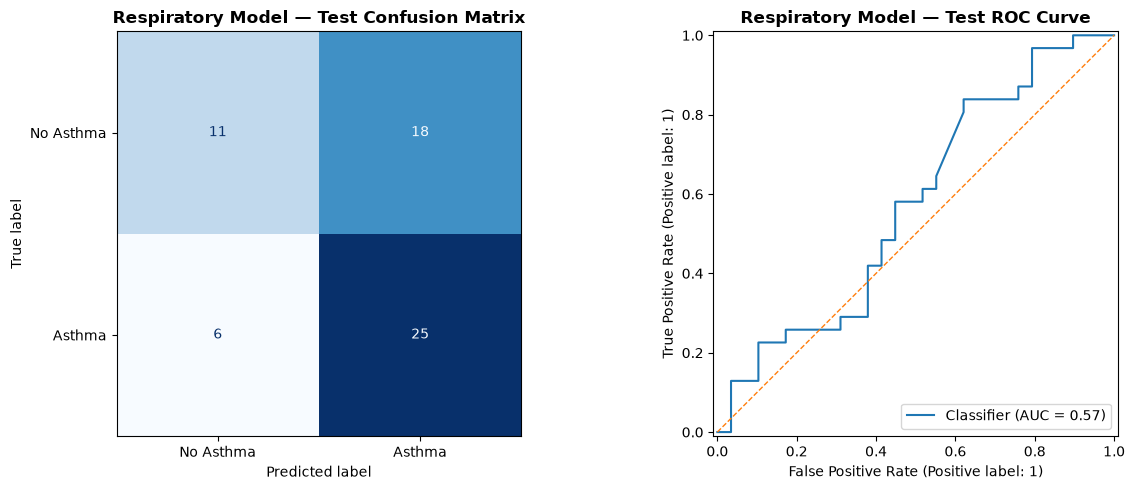

Evaluation figure saved: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\reports\figures\respiratory_model_evaluation.png


In [10]:
# Visualize final test-set performance
figure, axes = plt.subplots(
    1,
    2,
    figsize=(13, 5),
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction,
    display_labels=[
        "No Asthma",
        "Asthma",
    ],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)

axes[0].set_title(
    "Respiratory Model — Test Confusion Matrix",
    fontweight="bold",
)

RocCurveDisplay.from_predictions(
    y_test,
    test_probability,
    ax=axes[1],
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Respiratory Model — Test ROC Curve",
    fontweight="bold",
)

plt.tight_layout()

evaluation_figure_path = (
    figures_folder
    / "respiratory_model_evaluation.png"
)

plt.savefig(
    evaluation_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "Evaluation figure saved:",
    evaluation_figure_path,
)

## Dataset-quality warning

This dataset contains only **300 records** and only four non-leaking predictors. If ROC-AUC or balanced accuracy is close to `0.50`, the available variables do not contain enough reliable predictive signal.

Do **not** add `Medication` merely to increase accuracy; doing so would leak the diagnosis into the input and create misleading results.

The saved model is intended for an educational machine-learning demonstration, not clinical use.


In [11]:
# Print an explicit performance-quality warning
test_auc = test_metrics["ROC-AUC"]
test_balanced_accuracy = test_metrics[
    "Balanced Accuracy"
]

if (
    test_auc < 0.60
    or test_balanced_accuracy < 0.60
):
    print(
        "WARNING: The held-out performance is weak. "
        "The dataset appears to contain limited predictive signal "
        "after leakage-prone fields are removed."
    )
    print(
        "For a stronger academic project, consider replacing this "
        "dataset with a larger respiratory dataset containing "
        "clinically relevant pre-diagnosis predictors."
    )
else:
    print(
        "The model shows useful discrimination on the held-out "
        "test set, while still requiring cautious interpretation."
    )

For a stronger academic project, consider replacing this dataset with a larger respiratory dataset containing clinically relevant pre-diagnosis predictors.


In [12]:
# Save the selected pipeline and metadata for Streamlit
model_artifact = {
    "model": best_pipeline,
    "threshold": decision_threshold,
    "features": feature_columns,
    "numerical_features": numerical_features,
    "categorical_features": categorical_features,
    "target": target_column,
    "target_mapping": {
        0: "No Asthma",
        1: "Asthma",
    },
    "selected_model": best_model_name,
    "validation_results": (
        validation_results
        .round(6)
        .to_dict(orient="records")
    ),
    "test_metrics": {
        key: float(value)
        for key, value in test_metrics.items()
    },
    "random_state": RANDOM_STATE,
    "notes": (
        "Educational asthma screening model. "
        "Patient_ID excluded as identifier; Medication excluded "
        "to prevent target leakage."
    ),
}

joblib.dump(
    model_artifact,
    model_output_path,
)

print(
    "Model artifact saved successfully:",
    model_output_path,
)
print(
    "File exists:",
    model_output_path.exists(),
)
print(
    "Selected model:",
    model_artifact["selected_model"],
)
print(
    "Threshold:",
    round(model_artifact["threshold"], 4),
)
print(
    "Features:",
    model_artifact["features"],
)

Model artifact saved successfully: d:\1. My Files in Collage\5th Level\AI\Multi_Disease_ML_System\models\respiratory_disease_model.joblib
File exists: True
Selected model: Support Vector Machine
Threshold: 0.495
Features: ['age', 'gender', 'smoking_status', 'peak_flow']


In [13]:
# Reload the saved artifact and perform a sanity check
reloaded_artifact = joblib.load(
    model_output_path
)

reloaded_model = reloaded_artifact["model"]
reloaded_threshold = float(
    reloaded_artifact["threshold"]
)

sample_patient = pd.DataFrame(
    [
        {
            "age": 40,
            "gender": "female",
            "smoking_status": "non_smoker",
            "peak_flow": 300,
        }
    ]
)

sample_score = float(
    reloaded_model.predict_proba(
        sample_patient
    )[0, 1]
)

sample_prediction = int(
    sample_score >= reloaded_threshold
)

print("Sanity-check sample:")
display(sample_patient)

print(
    "Model score:",
    round(sample_score, 4),
)

print(
    "Predicted class:",
    reloaded_artifact[
        "target_mapping"
    ][sample_prediction],
)

print("\nArtifact keys:")
print(
    list(
        reloaded_artifact.keys()
    )
)

Sanity-check sample:


,age,gender,smoking_status,peak_flow
0,40,female,non_smoker,300


Model score: 0.5052
Predicted class: Asthma

Artifact keys:
['model', 'threshold', 'features', 'numerical_features', 'categorical_features', 'target', 'target_mapping', 'selected_model', 'validation_results', 'test_metrics', 'random_state', 'notes']


## Output

After successful execution, the notebook creates:

```text
models/respiratory_disease_model.joblib
reports/figures/respiratory_model_evaluation.png
```
